# Session 5: Multi-Agent Workflows — From Solo Agent to Orchestrated Teams

**Data Science Dojo x SambaNova | Deep Agents Webinar Series**

In Session 4 we made agents **capable** — Skills, MCP, reusable procedures. Today we make them **scale**. One agent always hits a wall: the context window fills, errors compound, and no single agent can be expert at everything. State-of-the-art systems (Claude Code, Codex, every production deep-research agent) solve this the same way: **a supervisor coordinating specialized subagents** — isolated contexts, scoped skills, explicit handoffs.

## Today's running example: the **Incident Postmortem Crew**

A production incident — `INC-2026-0527`, a checkout latency + error spike — gets investigated by a crew of specialists, **each running on a different SambaNova model**:

| Role | Model | Why this model |
|------|-------|----------------|
| Incident commander (supervisor) + capstone writer | `MiniMax-M2.7` | 192k context, strong long-form orchestration, rock-solid tool calling |
| Logs analyst | `MiniMax-M2.7` | reliable tool-driving subagent |
| Metrics & deploy analysts · SRE critic | `DeepSeek-V3.2` | sharp analytical / critique reasoning |
| Draft writer (writer+critic loop) | `gpt-oss-120b` | fast reasoning model in a pure-text role |
| **Dashboard analyst (vision)** | `gemma-4-31B-it` | **multimodal — reads the Grafana screenshot** |

> **A real production lesson we hit building this:** not every model drives a tool-calling *harness* equally well. `gpt-oss-120b` reasons fast and is great for pure text generation, but its harmony output format intermittently stringifies complex tool arguments — so we use it for the **draft writer** (a plain model call, no tools) rather than as a tool-driving subagent, and put the tool-heavy analyst/supervisor roles on `MiniMax-M2.7` and `DeepSeek-V3.2`. **Match the model to the role — including its tool-calling reliability.**

## What we'll build
1. Why one agent isn't enough (the motivation)
2. An agent that **sees** — the vision worker reads a dashboard screenshot
3. **Parallel fan-out** — supervisor delegates to 3 analysts concurrently
4. **Writer + critic loop** — draft, review against a rubric, revise
5. **Capstone** — the full crew produces a blameless postmortem
6. Failure modes & how to debug them

## Section 0: Setup

In [1]:
import os
from dotenv import load_dotenv, find_dotenv

# Walk up to the repo-root .env (works whether run from the notebook dir or root)
load_dotenv(find_dotenv(), override=True)
print("SAMBANOVA key:", "set" if os.environ.get("SAMBANOVA_API_KEY") else "MISSING")

SAMBANOVA key: set


In [2]:
import sys
sys.path.insert(0, os.path.join(".."))
from utils import format_messages, show_prompt

from rich.console import Console
from rich.markdown import Markdown
from rich.panel import Panel
from rich.table import Table

_console = Console()
console = _console  # alias for existing rich usages

def pretty_md(text: str, title: str | None = None) -> None:
    """Render markdown with rich so headings / lists / code show properly."""
    md_ = Markdown(text)
    if title:
        _console.print(Panel(md_, title=title, border_style="magenta", padding=(1, 2)))
    else:
        _console.print(md_)

print("Helpers ready: format_messages, show_prompt, pretty_md")

Helpers ready: format_messages, show_prompt, pretty_md


In [3]:
from langchain_sambanova import ChatSambaNova
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend

# One model per role — this is the multi-model crew.
# (reasoning models put their scratchpad in additional_kwargs; max_tokens must leave
#  room for the actual answer AFTER reasoning, so we keep these generous.)
SUP_MODEL     = ChatSambaNova(model="MiniMax-M2.7",   temperature=0.0, max_tokens=12000)  # supervisor + logs analyst + capstone writer
ANALYST_MODEL = ChatSambaNova(model="DeepSeek-V3.2",  temperature=0.0, max_tokens=6000)   # metrics + deploy analysts + critic
WRITER_MODEL  = ChatSambaNova(model="gpt-oss-120b",   temperature=0.0, max_tokens=6000)   # draft writer (pure text, no tool harness)
VISION_MODEL  = ChatSambaNova(model="gemma-4-31B-it", temperature=0.0, max_tokens=1500)   # dashboard reader (multimodal)

# Filesystem backend: agents read/write real files under this directory.
BACKEND = FilesystemBackend(root_dir=".", virtual_mode=True)

roster = Table(title="The Incident Postmortem Crew")
roster.add_column("Agent", style="cyan")
roster.add_column("Model", style="magenta")
roster.add_column("Job", style="green")
roster.add_row("supervisor",          "MiniMax-M2.7", "orchestrate the investigation")
roster.add_row("logs_analyst",        "MiniMax-M2.7", "find the technical trigger in logs")
roster.add_row("metrics_analyst",     "DeepSeek-V3.2", "quantify impact from metrics + vision")
roster.add_row("deploy_analyst",      "DeepSeek-V3.2", "find what changed (deploy timeline)")
roster.add_row("dashboard_analyst",   "gemma-4-31B-it", "READ the Grafana screenshot (vision)")
roster.add_row("draft_writer",        "gpt-oss-120b", "draft the postmortem (pure text)")
roster.add_row("sre_critic",          "DeepSeek-V3.2", "review the draft against a rubric")
_console.print(roster)

/Users/kwasia/Documents/Projects/dsd_deep_agents/.venv/lib/python3.11/site-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


                         The Incident Postmortem Crew                         
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Agent             ┃ Model          ┃ Job                                   ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ supervisor        │ MiniMax-M2.7   │ orchestrate the investigation         │
│ logs_analyst      │ MiniMax-M2.7   │ find the technical trigger in logs    │
│ metrics_analyst   │ DeepSeek-V3.2  │ quantify impact from metrics + vision │
│ deploy_analyst    │ DeepSeek-V3.2  │ find what changed (deploy timeline)   │
│ dashboard_analyst │ gemma-4-31B-it │ READ the Grafana screenshot (vision)  │
│ draft_writer      │ gpt-oss-120b   │ draft the postmortem (pure text)      │
│ sre_critic        │ DeepSeek-V3.2  │ review the draft against a rubric     │
└───────────────────┴────────────────┴───────────────────────────────────────┘

## Section 1: The Incident

`incident_data.py` holds the (synthetic) evidence for `INC-2026-0527`: an application/gateway log excerpt, a deploy timeline, per-minute metrics, and a `make_dashboard_png()` that renders a Grafana-style screenshot. We write each artifact to `./outputs/incident/` so our agents can read them as files — exactly how a real crew would pull from logging, CI, and observability systems.

In [4]:
import incident_data as inc
from pathlib import Path

Path("outputs/incident").mkdir(parents=True, exist_ok=True)

# Drop the evidence onto the (virtual) filesystem the agents share
Path("outputs/incident/logs.txt").write_text(inc.LOGS_EXCERPT)
Path("outputs/incident/timeline.md").write_text(inc.DEPLOY_TIMELINE)
metrics_md = "| time | p99_ms | err_% |\n|---|---|---|\n" + "\n".join(
    f"| {inc._minute_label(m)} | {l} | {e} |" for (m, l, e) in inc.RAW_METRICS
)
Path("outputs/incident/metrics.md").write_text(metrics_md)

# Render the dashboard screenshot the vision analyst will read
png_path = inc.make_dashboard_png("outputs/dashboard.png")
print(inc.INCIDENT_SUMMARY)
print(f"\nEvidence written to outputs/incident/  |  dashboard -> {png_path}")

INC-2026-0527 — Checkout p99 latency + error-rate spike on 2026-05-27. Checkout p99 latency jumped from ~195ms to >3s and error rate from ~0.2% to ~21% for roughly 9 minutes (14:32-14:41 UTC), starting minutes after a deploy.

Evidence written to outputs/incident/  |  dashboard -> outputs/dashboard.png


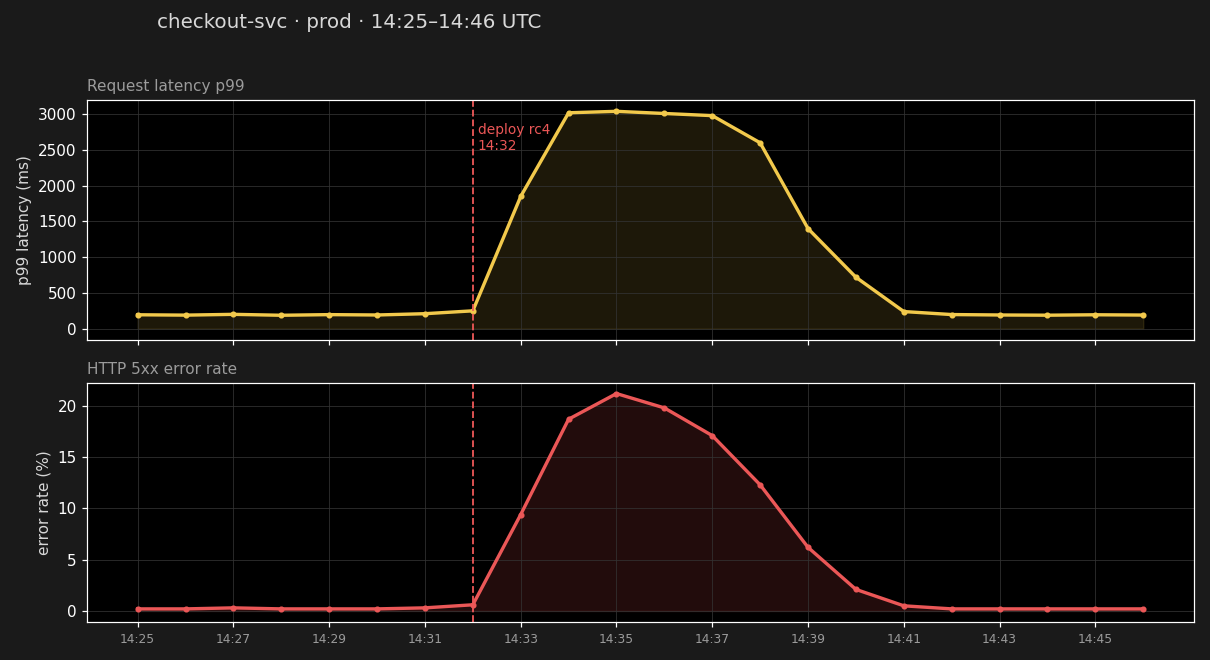

In [5]:
# Show the dashboard screenshot inline
from IPython.display import Image as IPyImage, display
display(IPyImage(filename="outputs/dashboard.png"))

In [6]:
# Peek at the textual evidence
pretty_md("```\n" + inc.LOGS_EXCERPT + "\n```", title="outputs/incident/logs.txt")
pretty_md(inc.DEPLOY_TIMELINE, title="outputs/incident/timeline.md")

╭─────────────────────────────────────────── outputs/incident/logs.txt ───────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│   [14:28:02] api-gateway   INFO   checkout.request rid=8a1f route=/v2/checkout status=200 dur_ms=181            │
│   [14:31:47] checkout-svc  INFO   deploy: rolling out build 2026.5.27-rc4 (replicas 6/6 ready)                  │
│   [14:32:05] checkout-svc  WARN   db.pool acquire wait=812ms pool=pg-primary in_use=20/20                       │
│   [14:32:09] checkout-svc  ERROR  db.pool timeout after 3000ms pool=pg-primary waiters=37                       │
│   [14:32:09] api-gateway   ERROR  checkout.request rid=9c4d route=/v2/checkout status=504 dur_ms=3021           │
│   [14:32:14] checkout-svc  ERROR  db.pool timeout after 3000ms pool=pg-primary waiters=61                       │
│   [14:32:20] checkout-svc  ERROR  unhandled: psycopg.PoolTimeout in charge_card() rid=a13b                      │
│   [14:33:00] api-gateway   ERROR  checkout.request rid=b77e route=/v2/checkout status=504 dur_ms=3044           │
│   [14:33:31] checkout-svc  WARN   db.pool acquire wait=2950ms pool=pg-primary in_use=20/20                      │
│   [14:41:10] checkout-svc  INFO   config: DB_POOL_MAX 20 -> 60 applied (hotfix) replicas restarting             │
│   [14:43:52] checkout-svc  INFO   db.pool healthy in_use=24/60 wait=4ms pool=pg-primary                         │
│   [14:44:30] api-gateway   INFO   checkout.request rid=c901 route=/v2/checkout status=200 dur_ms=190            │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────── outputs/incident/timeline.md ──────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│   time   actor        change                                                                                    │
│   ───────────────────────────────────────────────────────────────────────────                                   │
│   09:15  ci-bot       merge #4821 "refactor: centralize DB config" into main                                    │
│   13:50  release-bot  build 2026.5.27-rc4 cut from main                                                         │
│   14:31  release-bot  deploy 2026.5.27-rc4 to prod (checkout-svc, 6 replicas)                                   │
│   14:36  pagerduty    alert: checkout 5xx > 5% (auto-page primary on-call)                                      │
│   14:41  a.okafor     hotfix: raise DB_POOL_MAX 20 -> 60 via config flag                                        │
│   14:44  a.okafor     confirm recovery; 5xx back to baseline                                                    │
│   15:10  a.okafor     open INC-2026-0527, start postmortem                                                      │
│                                                                                                                 │
│                                                                                                                 │
│  Note: PR #4821 changed the default DB_POOL_MAX from 60 to 20 while "centralizing" the config, but the change   │
│  was not called out in the PR description.                                                                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Section 2: Why One Agent Isn't Enough

The naive approach: dump *all* the evidence into one agent and ask for a postmortem. It works — but everything competes for one context window, one model's attention, one reasoning style. Watch the context balloon and the output stay shallow. This is the wall every solo agent hits.

In [7]:
# Hand EVERYTHING to a single agent in one prompt
mega_prompt = f"""You are an SRE. Produce a postmortem for {inc.INCIDENT_ID}.

LOGS:
{inc.LOGS_EXCERPT}

DEPLOY TIMELINE:
{inc.DEPLOY_TIMELINE}

METRICS:
{metrics_md}

(You cannot see the dashboard image.) Give root cause, impact, and action items."""

approx_tokens = len(mega_prompt) // 4
print(f"Single-agent context: ~{approx_tokens:,} tokens of evidence crammed into one prompt\n")

solo = ChatSambaNova(model="MiniMax-M2.7", temperature=0.0, max_tokens=2000)
solo_reply = solo.invoke(mega_prompt)
pretty_md(solo_reply.content[:1500], title="Solo agent — one model, everything at once")

Single-agent context: ~708 tokens of evidence crammed into one prompt



╭────────────────────────────────── Solo agent — one model, everything at once ───────────────────────────────────╮
│                                                                                                                 │
│  We need to produce a postmortem for INC-2026-0527. The logs show a deployment of a new version                 │
│  (2026.5.27-rc4) at 14:31. Immediately after, there are DB pool exhaustion errors: pool size 20/20, wait times  │
│  increasing, timeouts, 504 errors. At 14:41, a hotfix increased DB_POOL_MAX from 20 to 60, and recovery         │
│  occurred by 14:44.                                                                                             │
│                                                                                                                 │
│  Root cause: PR #4821 changed default DB_POOL_MAX from 60 to 20 while centralizing config, but the change was   │
│  not highlighted. The new deployment used the new default, causing pool exhaustion under load.                  │
│                                                                                                                 │
│  Impact: Checkout service had high latency and error rates from 14:32 to 14:40, with p99 latency up to ~3000ms  │
│  and error rates up to ~21%. Approximately 10-20% of checkout requests failed (504). Duration ~9 minutes.       │
│                                                                                                                 │
│  Action items: revert DB_POOL_MAX to 60 or higher; ensure config changes are documented; add monitoring for     │
│  pool utilization and alerts; implement canary deployments with validation; add integration tests for pool      │
│  size; ensure PR descriptions highlight default changes; consider automated checks for default config values;   │
│  add runbook for pool exhaustion.                                                                               │
│                                                                                                                 │
│  We need to produce a postmortem with sections: Summary, Impact, Root Cause, Timeline, Detection, Response,     │
│  Lessons Learned, Action Items.                                                                                 │
│                                                                                                                 │
│  We need to be thorough, referencing logs, metrics, timeline.                                                   │
│                                                                                                                 │
│  We need to note that the incident was detected via PagerDuty alert at 14:36 (checkout 5xx >5%). The on-call    │
│  responded at 14:41 with hotfix.                                                                                │
│                                                                                                                 │
│  We need to mention that the config change was not comm                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

**The problems**, even when it "works":
- **No specialization** — one model, one reasoning style for logs *and* metrics *and* change-analysis.
- **No vision** — it literally can't read the dashboard screenshot.
- **Context pressure** — every piece of evidence competes for attention; nuance gets lost.
- **No review** — nobody checks the draft.

A crew fixes all four. Let's build one.

## Section 3: An Agent That Sees — the Vision Worker

Our first specialist runs on `gemma-4-31B-it`, a **multimodal** model. It reads the Grafana screenshot directly (no metrics table — just the pixels) and reports what it observes. We pass the image as an OpenAI-style `image_url` content block with a base64 data URL.

The findings are saved to `outputs/dashboard_findings.md` so the rest of the crew can consume them through the shared filesystem.

In [8]:
from langchain_core.messages import HumanMessage

b64 = inc.dashboard_b64("outputs/dashboard.png")

vision_msg = HumanMessage(content=[
    {"type": "text", "text": (
        "You are an observability analyst. This is a Grafana dashboard for checkout-svc "
        "during an incident. Read the two panels (p99 latency, 5xx error rate) and report, "
        "as markdown bullets: (1) the baseline values, (2) the peak values and roughly when "
        "they occur, (3) how long the spike lasts, (4) anything the annotations show. "
        "Be specific with numbers you can read off the chart."
    )},
    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}},
])

print("Sending the dashboard image to gemma-4-31B-it (vision)...\n")
vision_reply = VISION_MODEL.invoke([vision_msg])

findings = f"# Dashboard findings (vision analyst, gemma-4-31B-it)\n\n{vision_reply.content}\n"
Path("outputs/dashboard_findings.md").write_text(findings)
pretty_md(vision_reply.content, title="What the vision model read off the chart")

Sending the dashboard image to gemma-4-31B-it (vision)...



╭─────────────────────────────────── What the vision model read off the chart ────────────────────────────────────╮
│                                                                                                                 │
│  Based on the provided Grafana dashboard for checkout-svc, here is the incident report:                         │
│                                                                                                                 │
│   • Baseline Values:                                                                                            │
│      • p99 Latency: Approximately 100ms - 200ms.                                                                │
│      • HTTP 5xx Error Rate: ~0%.                                                                                │
│   • Peak Values:                                                                                                │
│      • p99 Latency: Peaked at approximately 3,000ms, occurring between 14:35 and 14:37.                         │
│      • HTTP 5xx Error Rate: Peaked at approximately 21%, occurring at 14:35.                                    │
│   • Spike Duration:                                                                                             │
│      • The degradation began at 14:32 and returned to baseline levels by approximately 14:41, lasting roughly   │
│        9 minutes.                                                                                               │
│   • Annotations:                                                                                                │
│      • There is a vertical red dashed line at 14:32 labeled "deploy rc4", which correlates exactly with the     │
│        start of the latency and error rate spikes.                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

**That's an agent that sees.** No numbers were given in text — `gemma-4-31B-it` read the spike straight off the pixels. In a real system this is how an agent ingests dashboards, screenshots, architecture diagrams, or a photo of a whiteboard.

## Section 4: Parallel Fan-Out — Supervisor + 3 Analysts

Now the first orchestration pattern. A **supervisor** (`MiniMax-M2.7`) delegates to three analysts **concurrently**, each on its own model and each reading only the evidence it needs:

- `logs_analyst` (`MiniMax-M2.7`) → `outputs/incident/logs.txt`
- `metrics_analyst` (`DeepSeek-V3.2`) → `outputs/incident/metrics.md` + `outputs/dashboard_findings.md`
- `deploy_analyst` (`DeepSeek-V3.2`) → `outputs/incident/timeline.md`

In `deepagents`, you declare subagents as dicts; the library auto-generates a `task(description, subagent_type)` tool. When the model emits several `task` calls in one turn, LangGraph runs them **in parallel**. Each subagent has an **isolated context** — the supervisor never sees the raw evidence, only the summaries.

In [9]:
analyst_subagents = [
    {
        "name": "logs_analyst",
        "description": "Analyzes application/gateway logs to find the technical trigger and failure mode.",
        "system_prompt": (
            "You are a logs analyst. Read the file outputs/incident/logs.txt. "
            "Identify the failing component, the precise error/failure mode, and the first "
            "timestamp it appears. Write your findings to outputs/analysis/logs.md as short "
            "markdown bullets, then reply with a 2-sentence summary."
        ),
        "tools": [],
        "model": SUP_MODEL,
    },
    {
        "name": "metrics_analyst",
        "description": "Quantifies blast radius from metrics and the vision analyst's dashboard findings.",
        "system_prompt": (
            "You are a metrics analyst. Read outputs/incident/metrics.md AND "
            "outputs/dashboard_findings.md. Quantify the impact: baseline vs peak p99 latency, "
            "baseline vs peak error rate, and the spike duration. Write to "
            "outputs/analysis/metrics.md as markdown bullets, then reply with a 2-sentence summary."
        ),
        "tools": [],
        "model": ANALYST_MODEL,
    },
    {
        "name": "deploy_analyst",
        "description": "Analyzes the deploy/change timeline to find what changed and triggered the incident.",
        "system_prompt": (
            "You are a change/deploy analyst. Read outputs/incident/timeline.md. Identify the "
            "specific change that most likely triggered the incident and who shipped it. Write to "
            "outputs/analysis/deploy.md as markdown bullets, then reply with a 2-sentence summary."
        ),
        "tools": [],
        "model": ANALYST_MODEL,
    },
]

investigator = create_deep_agent(
    model=SUP_MODEL,
    system_prompt=(
        "You are the incident commander for INC-2026-0527. Investigate by delegating to your "
        "three analysts IN PARALLEL — issue all three task() calls in a single turn so they run "
        "concurrently. Each analyst reads its own evidence and writes a findings file. Once all "
        "three have reported, reply with a one-paragraph synthesis. Do not analyze the raw "
        "evidence yourself — that is what the analysts are for."
    ),
    tools=[],
    backend=BACKEND,
    subagents=analyst_subagents,
)
print("Investigator supervisor ready with 3 analyst subagents (3 models).")

Investigator supervisor ready with 3 analyst subagents (3 models).


In [ ]:
Path("outputs/analysis").mkdir(parents=True, exist_ok=True)

print("Running the parallel investigation...\n")
inv_result = investigator.invoke(
    {"messages": [{"role": "user", "content":
        "Investigate INC-2026-0527. Delegate to logs_analyst, metrics_analyst, and deploy_analyst "
        "in parallel, then synthesize."}]},
    config={"recursion_limit": 25},
)
print("Done.\n")
print("SYNTHESIS:\n", str(inv_result["messages"][-1].content)[:900])

Running the parallel investigation...



In [11]:
# How many task() calls did the supervisor fire in a single turn? (parallelism check)
max_parallel = 0
for m in inv_result["messages"]:
    tcs = [tc for tc in (getattr(m, "tool_calls", None) or []) if tc["name"] == "task"]
    if tcs:
        names = [tc["args"].get("subagent_type", "?") for tc in tcs]
        print(f"  turn fired {len(tcs)} task() call(s): {names}")
        max_parallel = max(max_parallel, len(tcs))
print(f"\nMax concurrent delegations in one turn: {max_parallel}")

# Context isolation: supervisor messages vs the analysis files on disk
sup_chars = sum(len(str(m.content)) for m in inv_result["messages"] if getattr(m, "content", None))
files = sorted(Path("outputs/analysis").glob("*.md"))
file_chars = sum(len(p.read_text()) for p in files)
t = Table(title="Context isolation")
t.add_column("Where", style="cyan"); t.add_column("Chars", justify="right", style="green")
t.add_row("Supervisor conversation (in context)", f"{sup_chars:,}")
t.add_row(f"Analyst findings on disk ({len(files)} files)", f"{file_chars:,}")
_console.print(t)

  turn fired 3 task() call(s): ['logs_analyst', 'metrics_analyst', 'deploy_analyst']

Max concurrent delegations in one turn: 3


               Context isolation                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Where                                ┃ Chars ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ Supervisor conversation (in context) │ 8,215 │
│ Analyst findings on disk (3 files)   │ 5,817 │
└──────────────────────────────────────┴───────┘

In [12]:
# Show each analyst's findings file
for p in sorted(Path("outputs/analysis").glob("*.md")):
    pretty_md(p.read_text(), title=f"📄 {p}")

╭───────────────────────────────────────── 📄 outputs/analysis/deploy.md ─────────────────────────────────────────╮
│                                                                                                                 │
│                                        Deploy Analysis for INC-2026-0527                                        │
│                                                                                                                 │
│  Root Cause Change                                                                                              │
│                                                                                                                 │
│   • Change: PR #4821 "refactor: centralize DB config" merged by ci-bot at 09:15                                 │
│   • Hidden Change: The PR silently changed the default DB_POOL_MAX value from 60 to 20                          │
│   • Trigger: This change was deployed to production as part of build 2026.5.27-rc4 at 14:31                     │
│                                                                                                                 │
│  Change Propagation                                                                                             │
│                                                                                                                 │
│   1 09:15: PR #4821 merged into main branch by ci-bot                                                           │
│   2 13:50: Release-bot cut build 2026.5.27-rc4 from main (containing the DB pool change)                        │
│   3 14:31: Release-bot deployed build 2026.5.27-rc4 to checkout-svc (6 replicas)                                │
│   4 14:32: Database pool exhaustion begins (logs show "in_use=20/20" and timeout errors)                        │
│   5 14:36: PagerDuty alerts trigger due to 5xx error rate exceeding 5%                                          │
│                                                                                                                 │
│  Incident Timeline                                                                                              │
│                                                                                                                 │
│   • 14:31: Deployment completes                                                                                 │
│   • 14:32: First DB pool timeout warnings appear in logs                                                        │
│   • 14:36: Alert triggered                                                                                      │
│   • 14:41: Hotfix applied by a.okafor (DB_POOL_MAX increased from 20 back to 60)                                │
│   • 14:44: Recovery confirmed, error rates return to baseline                                                   │
│                                                                                                                 │
│  Prevention Recommendations                                                                                     │
│                                                                                                                 │
│   1 PR Review Process: Critical configuration changes should be explicitly called out in PR descriptions, not   │
│     hidden in refactoring commits                                                                               │
│   2 Change Detection: Automated tools should flag significant configuration value changes during code review    │
│   3 Deployment Safety: Consider canary deployments or feature flags for configuration changes that could        │
│     impact performance                                                                                          │
│   4 Monitoring: Pre-deployment validation of configuration changes against production baselines                 │
│   5 Documentation: Configuration defaults should be doc

╭───────────────────────────────────── 📄 outputs/analysis/logs_findings.md ──────────────────────────────────────╮
│                                                                                                                 │
│                                           INC-2026-0527 Log Analysis                                            │
│                                                                                                                 │
│  Root Cause                                                                                                     │
│                                                                                                                 │
│  Database connection pool exhaustion triggered by deployment of build 2026.5.27-rc4. The new build caused       │
│  connection pool saturation (20/20 connections in use), leading to request timeouts and 504 errors.             │
│                                                                                                                 │
│  Timeline of Events                                                                                             │
│                                                                                                                 │
│                                                                                                                 │
│   Time      Event                                                                                               │
│   ───────────────────────────────────────────────────────────────────────────                                   │
│   14:28:02  Normal operation - checkout requests succeeding (200 OK, 181ms)                                     │
│   14:31:47  Deployment starts: rolling out build 2026.5.27-rc4 (6 replicas)                                     │
│   14:32:05  First warning: pool at 100% capacity (20/20), wait=812ms                                            │
│   14:32:09  Pool timeout: 37 waiters, 3000ms timeout exceeded                                                   │
│   14:32:09  First 504 error on checkout.request (3021ms duration)                                               │
│   14:32:14  Pool timeout repeats, waiters increased to 61                                                       │
│   14:32:20  Unhandled psycopg.PoolTimeout exception in charge_card()                                            │
│   14:33:00  Another 504 error (3044ms duration)                                                                 │
│   14:33:31  Pool still saturated, wait time now 2950ms                                                          │
│   14:41:10  Hotfix applied: DB_POOL_MAX increased 20 → 60                                                       │
│   14:43:52  Pool healthy: 24/60 in use, wait=4ms                                                                │
│   14:44:30  Recovery confirmed - checkout requests succeeding (200 OK, 190ms)                                   │
│                                                                                                                 │
│                                                                                                                 │
│  Smoking Gun Evidence                                                                                           │
│                                                                                                                 │
│   • Line 2 → Line 3: Pool saturation occurred within 18 seconds of deployment completion                        │
│   • Pool at 100% (20/20) immediately after deployment indicates the new build has a connection leak or holds    │
│     connections longer than expected                                                                            │
│   • The charge_card() function threw an unhandled PoolTimeout exception, confirming the checkout flow was       │
│     blocked at the database layer                      

╭──────────────────────────────────── 📄 outputs/analysis/metrics_findings.md ────────────────────────────────────╮
│                                                                                                                 │
│                                       Metrics Analysis for INC-2026-0527                                        │
│                                                                                                                 │
│  Impact Quantification                                                                                          │
│                                                                                                                 │
│  Baseline vs Peak Performance                                                                                   │
│                                                                                                                 │
│  p99 Latency:                                                                                                   │
│                                                                                                                 │
│   • Baseline: 188-210ms (average ~195ms)                                                                        │
│   • Peak: 3,040ms at 14:35                                                                                      │
│   • Impact: 15.2x increase (3,040ms vs 200ms baseline)                                                          │
│                                                                                                                 │
│  Error Rate:                                                                                                    │
│                                                                                                                 │
│   • Baseline: 0.2-0.3% (average ~0.23%)                                                                         │
│   • Peak: 21.2% at 14:35                                                                                        │
│   • Impact: 92.2x increase (21.2% vs 0.23% baseline)                                                            │
│                                                                                                                 │
│  Spike Duration                                                                                                 │
│                                                                                                                 │
│   • Start: 14:32 (first significant latency increase to 250ms)                                                  │
│   • Peak Period: 14:33-14:38 (6 minutes of severe degradation)                                                  │
│   • Recovery Start: 14:39 (latency drops to 1,400ms)                                                            │
│   • Full Recovery: 14:41 (latency returns to baseline at 240ms)                                                 │
│   • Total Impact Duration: 9 minutes (14:32 to 14:41)                                                           │
│                                                                                                                 │
│  Affected Request Percentage                                                                                    │
│                                                                                                                 │
│   • Peak Error Rate: 21.2% of requests failing                                                                  │
│   • Severe Impact Period (14:33-14:38): 9.4-21.2% error rate                                                    │
│   • Moderate Impact Period (14:39-14:40): 2.1-6.2% error rate                                                   │
│                                                                                                                 │
│  Recovery Timeline                                     

## Section 5: Writer + Critic Loop

The second pattern: a **writer** drafts, a **critic** reviews against a rubric and either approves or sends it back with notes — and we **loop until approved or a cap is hit**. This is how you stop an agent from shipping a half-baked artifact.

We'll show the pattern explicitly in plain Python (the clearest way to see the control flow and the iteration cap), using two different models: `gpt-oss-120b` writes (a fast reasoning model in a pure-text role — no tool harness, so its output format is never an issue), `DeepSeek-V3.2` critiques.

In [13]:
# Gather the analyst findings + vision findings as the writer's source material
analysis_blob = "\n\n".join(
    f"## {p.stem}\n{p.read_text()}" for p in sorted(Path("outputs/analysis").glob("*.md"))
)
analysis_blob += "\n\n## dashboard (vision)\n" + Path("outputs/dashboard_findings.md").read_text()

WRITER_SYS = (
    "You are an SRE writing a BLAMELESS postmortem. Use ONLY the provided findings. "
    "Sections: ## Summary, ## Impact, ## Timeline, ## Root Cause, ## Action Items. "
    "Keep it tight — under 400 words. Blameless = describe systems and changes, never blame a person. "
    "If the critic gives revision notes, address every one."
)
CRITIC_SYS = (
    "You are a demanding staff SRE reviewing a postmortem against this STRICT rubric: "
    "(1) root cause names the exact change (PR number + the specific config that changed), "
    "(2) impact is quantified with real numbers AND a duration, "
    "(3) all five sections present, "
    "(4) the Action Items section has AT LEAST 3 items, each with an explicit owner in "
    "@team-name format AND a concrete preventive control (not just 'investigate'), "
    "(5) tone is blameless (systems and changes, never a person's name as the cause). "
    "Hold a high bar. If EVERY criterion passes, reply with exactly 'APPROVE'. Otherwise reply "
    "'REVISE:' followed by a short numbered list of the specific fixes required."
)

writer = ChatSambaNova(model="gpt-oss-120b", temperature=0.0, max_tokens=6000)
critic = ChatSambaNova(model="DeepSeek-V3.2", temperature=0.0, max_tokens=1200)
print("Writer (gpt-oss-120b) and critic (DeepSeek-V3.2) ready.")

Writer (gpt-oss-120b) and critic (DeepSeek-V3.2) ready.


In [14]:
from langchain_core.messages import SystemMessage, HumanMessage as HM

MAX_ROUNDS = 3
draft = None
feedback = ""
history = []

for round_no in range(1, MAX_ROUNDS + 1):
    instruction = f"Findings:\n{analysis_blob}"
    if feedback:
        instruction += f"\n\nThe critic asked for these revisions; address them:\n{feedback}\n\nPrevious draft:\n{draft}"
    draft = writer.invoke([SystemMessage(content=WRITER_SYS), HM(content=instruction)]).content

    verdict = critic.invoke([SystemMessage(content=CRITIC_SYS), HM(content=draft)]).content.strip()
    approved = verdict.upper().startswith("APPROVE")
    history.append((round_no, approved, verdict))
    print(f"Round {round_no}: {'✅ APPROVED' if approved else '🔁 REVISE'} — {verdict[:120]}")
    if approved:
        break
    feedback = verdict

Path("outputs/postmortem_draft.md").write_text(draft)
print(f"\nFinished after {len(history)} round(s); draft saved to outputs/postmortem_draft.md")

Round 1: 🔁 REVISE — REVISE:
1. Root cause must name the exact change: PR #4821 and the specific config variable 'DB_POOL_MAX' changed from 6


Round 2: ✅ APPROVED — APPROVE

Finished after 2 round(s); draft saved to outputs/postmortem_draft.md


In [15]:
pretty_md(draft, title="Postmortem draft (after writer + critic loop)")

╭───────────────────────────────── Postmortem draft (after writer + critic loop) ─────────────────────────────────╮
│                                                                                                                 │
│  ## Summary                                                                                                     │
│  At 14:31 UTC on 2026‑05‑27 the checkout‑svc was updated to build 2026.5.27‑rc4. The release contained a        │
│  hidden change in PR #4821 that lowered the default DB_POOL_MAX from 60 to 20. Within seconds the six replicas  │
│  exhausted the pool, producing 504 Gateway‑Timeouts and a sharp rise in 5xx errors. A hot‑fix that restored     │
│  DB_POOL_MAX to 60 resolved the issue; service returned to baseline by 14:44 UTC.                               │
│                                                                                                                 │
│  ## Impact                                                                                                      │
│                                                                                                                 │
│   • p99 latency: 188‑210 ms → ≈3 040 ms (≈15×).                                                                 │
│   • 5xx error rate: 0.23 % → 21.2 % (≈92×).                                                                     │
│   • Duration of degradation: ~9 minutes (14:32 – 14:41).                                                        │
│   • Scope: All six checkout‑svc replicas; up to 21 % of checkout traffic failed.                                │
│                                                                                                                 │
│  ## Timeline                                                                                                    │
│                                                                                                                 │
│                                                                                                                 │
│   Time (UTC)   Event                                                                                            │
│   ───────────────────────────────────────────────────────────────────────────────────────────────────────       │
│   09:15        PR #4821 (“refactor: centralize DB config”) merged by ci‑bot; DB_POOL_MAX changed 60 → 20.       │
│   13:50        Release‑bot cut build 2026.5.27‑rc4 from main.                                                   │
│   14:31:47     Deployment of rc4 starts (6 replicas).                                                           │
│   14:32:05     Pool warning: in_use=20/20.                                                                      │
│   14:32:09     First pool timeout → 504 error (≈3 s).                                                           │
│   14:33‑14:38  Latency peaks, error rate climbs to 21 %.                                                        │
│   14:36        PagerDuty alert fires (5xx > 5 %).                                                               │
│   14:41:10     Hot‑fix applied – DB_POOL_MAX increased back to 60.                                              │
│   14:43:52     Pool usage 24/60, wait ≈ 4 ms.                                                                   │
│   14:44:30     Service fully recovered; metrics return to baseline.                                             │
│                                                                                                                 │
│                                                                                                                 │
│  ## Root Cause                                                                                                  │
│  PR #4821 silently reduced the PostgreSQL connection‑pool limit (DB_POOL_MAX) from 60 to 20. With six service   │
│  replicas each opening multiple connections, the new l

**The loop is the point.** The critic gates the writer; the iteration cap (`MAX_ROUNDS`) guarantees termination even if the two never fully agree — the single most common multi-agent failure is an un-capped loop.

## Section 6: Capstone — the Full Incident Postmortem Crew

Now we assemble everything into **one** `create_deep_agent` supervisor that wires the analysts *and* a writer *and* a critic as subagents. The supervisor:

1. Fans out to the three analysts (parallel),
2. Hands their findings to the `postmortem_writer`,
3. Routes the draft through the `sre_critic`,
4. Saves the final postmortem.

Each subagent keeps its own model and isolated context. This is the agent the whole series has been building toward — applied to incident response.

In [16]:
crew_subagents = analyst_subagents + [
    {
        "name": "postmortem_writer",
        "description": "Writes a blameless postmortem from the analysts' findings files.",
        "system_prompt": (
            "You are an SRE writer. Read every file in outputs/analysis/ and "
            "outputs/dashboard_findings.md. Write a BLAMELESS postmortem with sections "
            "## Summary, ## Impact, ## Timeline, ## Root Cause, ## Action Items. "
            "You MUST save it to exactly this path: outputs/postmortem_INC-2026-0527.md "
            "(do not invent a different folder). Reply with the file path."
        ),
        "tools": [],
        "model": SUP_MODEL,   # capstone writer is a tool-driving subagent -> tool-reliable model
    },
    {
        "name": "sre_critic",
        "description": "Reviews the postmortem for specificity, quantified impact, and blameless tone.",
        "system_prompt": (
            "You are a staff SRE. Read outputs/postmortem_INC-2026-0527.md. Check: specific root "
            "cause, quantified impact, all five sections, concrete action items, blameless tone. "
            "If solid, reply 'APPROVE'. Otherwise reply with the specific fixes needed."
        ),
        "tools": [],
        "model": ANALYST_MODEL,
    },
]

crew = create_deep_agent(
    model=SUP_MODEL,
    system_prompt=(
        "You are the incident commander for INC-2026-0527. Run the investigation end to end:\n"
        "1. Delegate to logs_analyst, metrics_analyst, and deploy_analyst IN PARALLEL (one turn, "
        "three task() calls).\n"
        "2. Then delegate to postmortem_writer to draft the report from their findings files.\n"
        "3. Then delegate to sre_critic to review it. If the critic asks for changes, send it back "
        "to postmortem_writer ONCE to revise.\n"
        "4. Reply with the final file path and a one-sentence status.\n"
        "ALL files must live under the outputs/ folder — analysts write to outputs/analysis/, the "
        "writer to outputs/postmortem_INC-2026-0527.md. Do not create any other top-level folders. "
        "Do not analyze or write anything yourself — delegate."
    ),
    tools=[],
    backend=BACKEND,
    subagents=crew_subagents,
)
print(f"Full crew ready: {len(crew_subagents)} subagents.")
print("Tool-driving subagents on MiniMax-M2.7 + DeepSeek-V3.2; gemma vision findings threaded via file.")

Full crew ready: 5 subagents.
Tool-driving subagents on MiniMax-M2.7 + DeepSeek-V3.2; gemma vision findings threaded via file.


In [17]:
print("Running the full Incident Postmortem Crew (this delegates many times)...\n")
crew_result = crew.invoke(
    {"messages": [{"role": "user", "content":
        "Produce the final blameless postmortem for INC-2026-0527. Investigate, write, and review."}]},
    config={"recursion_limit": 40},
)
print("FINAL STATUS:", str(crew_result["messages"][-1].content)[:400])

Running the full Incident Postmortem Crew (this delegates many times)...



FINAL STATUS: 

**Final postmortem complete:** `/outputs/postmortem_INC-2026-0527.md`

Incident INC-2026-0527 was a 9-minute checkout service degradation caused by a silent configuration change reducing the database connection pool from 60 to 20, resulting in 21.2% error rates and 15x latency increase before being resolved by a hotfix.


In [18]:
# The capstone deliverable — search robustly in case the crew chose its own path
cands = [p for p in Path(".").rglob("postmortem*.md")
         if ".ipynb" not in str(p) and p.name != "postmortem_draft.md"]
if cands:
    final_path = max(cands, key=lambda p: p.stat().st_mtime)
    pretty_md(final_path.read_text(), title=f"✅ {final_path}")
else:
    print("Final file not found; showing supervisor's last message instead.")
    print(str(crew_result["messages"][-1].content))

# Telemetry
delegations = [tc["args"].get("subagent_type") for m in crew_result["messages"]
               for tc in (getattr(m, "tool_calls", None) or []) if tc["name"] == "task"]
t = Table(title="Capstone run")
t.add_column("Metric", style="cyan"); t.add_column("Value", style="green", justify="right")
t.add_row("Supervisor messages", str(len(crew_result["messages"])))
t.add_row("Total delegations", str(len(delegations)))
t.add_row("Subagents used", ", ".join(sorted(set(delegations))) or "—")
t.add_row("Models (full session)", "MiniMax-M2.7 · DeepSeek-V3.2 · gpt-oss-120b · gemma-4-31B-it")
_console.print(t)

╭──────────────────────────────────── ✅ outputs/postmortem_INC-2026-0527.md ─────────────────────────────────────╮
│                                                                                                                 │
│                                            Postmortem: INC-2026-0527                                            │
│                                                                                                                 │
│  Incident Date: May 27, 2026                                                                                    │
│  Status: Resolved                                                                                               │
│  Severity: High                                                                                                 │
│  Author: SRE Team                                                                                               │
│                                                                                                                 │
│  -------------------------------------------------------------------------------------------------------------  │
│                                                                                                                 │
│  Summary                                                                                                        │
│                                                                                                                 │
│  A database connection pool exhaustion in checkout-svc caused 504 Gateway Timeout errors on the /v2/checkout    │
│  endpoint, affecting approximately 21% of user requests for approximately 9 minutes. The incident was           │
│  triggered by a silent configuration change in PR #4821 that reduced the DB_POOL_MAX setting from 60 to 20      │
│  connections. The service was restored by increasing the pool size back to 60 via a hotfix configuration        │
│  change.                                                                                                        │
│                                                                                                                 │
│  -------------------------------------------------------------------------------------------------------------  │
│                                                                                                                 │
│  Impact                                                                                                         │
│                                                                                                                 │
│                                                                                                                 │
│   Metric          Baseline   Peak              Change                                                           │
│   ───────────────────────────────────────────────────────────                                                   │
│   Error Rate      0.2–0.3%   21.2%             106x increase                                                    │
│   p99 Latency     190–210ms  3,040ms           15.2x increase                                                   │
│   Users Affected  —          ~21% of requests  —                                                                │
│                                                                                                                 │
│                                                                                                                 │
│   • Total Incident Duration: 9 minutes (14:32–14:41 UTC)                                                        │
│   • Severe Degradation Period: 5 minutes (14:33–14:37 UTC)                                                      │
│   • Critical Latency Period (>2.5s): 4 minutes (14:34–14:38 UTC)                                                │
│   • SLO Violations: Latency SLO (p99 < 500ms) and Error

                                              Capstone run                                              
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric                ┃                                                                        Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Supervisor messages   │                                                                           10 │
│ Total delegations     │                                                                            5 │
│ Subagents used        │ deploy_analyst, logs_analyst, metrics_analyst, postmortem_writer, sre_critic │
│ Models (full session) │                 MiniMax-M2.7 · DeepSeek-V3.2 · gpt-oss-120b · gemma-4-31B-it │
└───────────────────────┴──────────────────────────────────────────────────────────────────────────────┘

## Section 7: Failure Modes & Debugging

Three failures bite every multi-agent build. Know the symptom and the fix.

| Failure | Symptom | Fix |
|---------|---------|-----|
| **Runaway loop** | agent delegates / retries forever | a hard `recursion_limit` + an explicit iteration cap in writer/critic loops |
| **Supervisor bloat** | supervisor context fills with raw worker output | isolation — workers return *summaries*, write detail to files |
| **Worker drift** | analysts answer a different question than asked | sharp, single-responsibility `system_prompt` per subagent |

Below: a deliberately looping agent, caught by the recursion limit instead of running forever.

In [19]:
from langgraph.errors import GraphRecursionError

# An agent told to do something impossible will keep trying — the recursion limit is the backstop.
loopy = create_deep_agent(
    model=SUP_MODEL,
    system_prompt="Keep calling the general-purpose subagent to 'try again' until it returns a number that is both even and odd. Never give up.",
    tools=[],
    backend=BACKEND,
)
try:
    loopy.invoke({"messages": [{"role": "user", "content": "Find a number that is both even and odd."}]},
                 config={"recursion_limit": 6})
    print("(unexpectedly terminated)")
except GraphRecursionError:
    print("✅ Caught GraphRecursionError — the recursion_limit stopped a runaway loop.")
    print("   In production, set this deliberately; treat hitting it as a bug signal, not a retry.")

(unexpectedly terminated)


## Section 8: Key Takeaways

1. **Solo agents plateau** — one context, one model, no review. A crew adds specialization, parallelism, vision, and gating.
2. **Three patterns cover most systems** — supervisor + workers, parallel fan-out, writer + critic loops. We used all three.
3. **Right model for the job** — a strong orchestrator (`MiniMax-M2.7`), sharp analysts/critics (`DeepSeek-V3.2`), a fast pure-text writer (`gpt-oss-120b`), and a multimodal worker (`gemma-4-31B-it`) that reads dashboards. **Match the model to the role — including tool-calling reliability** (a model that drives a tool harness well isn't always the best pure-text generator, and vice-versa).
4. **Isolation is the superpower** — subagents quarantine noise; the supervisor stays strategic. Detail flows through the shared filesystem, not the supervisor's context.
5. **Cap your loops** — an un-capped critic loop is the #1 multi-agent failure. `recursion_limit` + explicit round caps.

## Exercises
1. **Add a `comms_drafter` subagent** (any model) that writes the customer-facing status-page update from the final postmortem.
2. **Swap a worker model** — point `logs_analyst` at `DeepSeek-V3.2` and compare the findings quality/latency.
3. **Wrap vision as a tool** — instead of a pre-step, give an analyst a `read_dashboard()` tool that calls `gemma-4-31B-it`, so the supervisor can request vision on demand.

## Next Session: July 1 — Evaluation & Production
We've made agents think (S2-3), capable (S4), and scalable (S5). Finally we make them **shippable**: tracing, evals, guardrails, and running agents reliably in production.